In [14]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### PCA因子计算

In [28]:
day = 1600 # setting
n_components = 40  # you can adjust the number of components as needed

In [16]:
raw_factor = pd.read_parquet(f'../data/output/Factor_compute_{day}.parquet')
raw_factor.head()

,date_id,time_id,factor_00,factor_01,factor_02,factor_03,factor_04,factor_05,factor_06,factor_07,...,factor_69,factor_70,factor_71,factor_72,factor_73,factor_74,factor_75,factor_76,factor_77,factor_78
0,1600,0,-0.388159,-0.392169,0.441118,0.292936,-0.237213,-0.460508,-0.240470,0.574319,...,-0.244297,-0.173421,-0.520945,-0.581773,0.484532,0.484532,-0.885424,-0.665936,-0.620816,-0.734692
1,1600,1,0.067690,-0.064246,0.524310,-0.047003,0.092722,0.067377,0.146826,0.081792,...,-0.095162,-0.245211,-0.547847,-0.489991,0.261285,0.261285,-0.353504,-0.556902,-0.571464,-0.305536
2,1600,2,-0.271670,-0.049937,-0.041185,-0.126318,-0.298443,0.008601,0.087331,-0.032065,...,0.233117,-0.342536,-0.450456,-0.376506,0.278819,0.278819,-0.361650,-0.431012,-0.294081,-0.222159
3,1600,3,0.109686,-0.004317,0.156303,0.069292,-0.402638,-0.033009,0.329742,0.064283,...,-0.040918,-0.183785,-0.453449,-0.588407,0.345269,0.345269,-0.059165,-0.200939,-0.027175,-0.027175
4,1600,4,-0.003057,0.075260,-0.053826,0.481526,0.045749,-0.141084,0.032314,0.258650,...,0.026715,-0.178769,-0.572487,-0.547269,0.520609,0.520609,-0.388066,-0.279394,-0.252856,-0.195233


In [17]:
# split index and feature columns
index_cols = ['date_id', 'time_id']
feature_cols = [col for col in raw_factor.columns if col not in index_cols]

# get the index and feature data
indices = raw_factor[index_cols].copy()
features = raw_factor[feature_cols].copy()

In [18]:
# Standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled[:5,:]

array([[-3.10572127e+00, -3.10736267e+00,  3.49326955e+00,
         2.32640791e+00, -1.88645757e+00, -3.51659466e+00,
        -1.84032612e+00,  4.41227035e+00,  3.08027785e-01,
        -2.69814790e+00, -1.88759757e+00, -4.31388824e+00,
        -1.95493449e+00,  1.53743793e+00, -1.26883889e+00,
         3.73662302e+00, -6.05750009e+00,  3.73155223e+00,
        -2.09722384e+00, -4.42849665e-01,  4.73822915e+00,
         2.64963886e+00,  3.37615334e+00,  2.83659156e+00,
        -5.92043959e-01, -6.02813060e-01,  2.05233523e+00,
         1.99912261e+00,  9.23940171e-01, -5.69853369e-01,
        -2.43523914e+00,  2.62932062e+00,  3.68470735e+00,
         3.60667107e+00, -1.04788040e-01, -2.84855260e+00,
         1.03039159e-01, -1.72981164e+00, -1.88338254e-01,
         3.43179966e+00,  1.51311467e+00,  3.50705679e+00,
         3.37590550e+00,  5.86152967e+00,  3.47063683e+00,
         2.69687739e-01,  2.83130425e+00,  2.36929689e+00,
         7.99369023e-01,  3.46478224e+00,  3.38813232e+0

In [19]:
# run PCA
pca = PCA()
pca_result = pca.fit_transform(features_scaled)
pca_result[:5,:]

array([[-1.10274315e+01, -2.83072726e+00, -1.07723732e+01,
        -4.54745189e-01, -2.92053395e+00, -3.16640717e+00,
         2.61010145e-01,  2.38101711e-01,  9.69321320e-01,
         2.93109035e+00, -1.67230686e+00,  8.85952665e-01,
         6.77586138e-01, -3.42132626e+00, -1.65586803e+00,
         3.69707655e+00,  4.80110590e-01, -1.02068246e+00,
         9.20140141e-01, -3.61114246e+00,  3.01383304e+00,
        -3.55331069e+00,  1.97013359e-01,  6.19735065e+00,
         1.29616309e-01, -2.85071705e+00,  1.70146623e-01,
         2.92284068e-01, -7.00640601e+00, -6.22308318e+00,
        -6.92788467e+00, -4.27261778e+00,  2.97595149e+00,
        -5.52213606e+00,  5.40934838e+00,  2.47730976e+00,
         1.02267267e+00, -1.17353671e+00,  1.75500121e+00,
         2.82811283e+00,  2.85446836e-01,  1.36934896e+00,
         1.27573131e+00,  1.04938856e+00,  1.97772932e+00,
         1.43700498e+00,  2.45616420e+00, -2.53991054e+00,
         2.51971531e+00, -1.93782083e+00, -3.15394943e+0

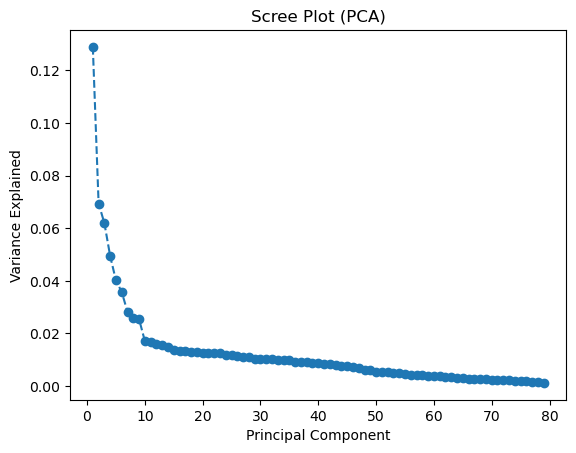

In [20]:
# Scree Plot
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Scree Plot (PCA)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

In [32]:
pca.explained_variance_ratio_

array([0.12888853, 0.06938449, 0.06191019, 0.0494358 , 0.04014356,
       0.03578426, 0.02819792, 0.02606183, 0.02540843, 0.01717178,
       0.01667749, 0.01593047, 0.01553429, 0.0146836 , 0.01371692,
       0.01344654, 0.01315545, 0.01289895, 0.01279773, 0.01269064,
       0.0126107 , 0.01257093, 0.01246403, 0.01198848, 0.01178508,
       0.0113317 , 0.0111245 , 0.01087934, 0.01049183, 0.01042896,
       0.01030562, 0.01020465, 0.00993408, 0.00981714, 0.00975582,
       0.00928751, 0.00917936, 0.0090412 , 0.00886188, 0.00871136,
       0.00858418, 0.00841332, 0.00814231, 0.00777552, 0.007523  ,
       0.00729079, 0.00675719, 0.00610114, 0.00595417, 0.00550724,
       0.00535326, 0.00524048, 0.00512509, 0.00488625, 0.00452171,
       0.00432742, 0.00414576, 0.00405601, 0.00399766, 0.00385313,
       0.00369321, 0.0035987 , 0.00343044, 0.00320484, 0.00302932,
       0.00288266, 0.00281497, 0.00278666, 0.00269252, 0.00244318,
       0.00237021, 0.00225832, 0.00215516, 0.00212637, 0.00203

In [23]:
pca.explained_variance_ratio_.cumsum()

array([0.12888853, 0.19827303, 0.26018322, 0.30961902, 0.34976258,
       0.38554684, 0.41374476, 0.43980659, 0.46521502, 0.4823868 ,
       0.49906429, 0.51499476, 0.53052905, 0.54521265, 0.55892957,
       0.57237612, 0.58553157, 0.59843052, 0.61122825, 0.62391889,
       0.63652959, 0.64910052, 0.66156454, 0.67355303, 0.6853381 ,
       0.6966698 , 0.70779431, 0.71867364, 0.72916547, 0.73959443,
       0.74990005, 0.7601047 , 0.77003879, 0.77985593, 0.78961175,
       0.79889926, 0.80807862, 0.81711982, 0.8259817 , 0.83469306,
       0.84327725, 0.85169057, 0.85983288, 0.8676084 , 0.8751314 ,
       0.88242219, 0.88917937, 0.89528051, 0.90123469, 0.90674193,
       0.91209519, 0.91733567, 0.92246076, 0.92734702, 0.93186873,
       0.93619615, 0.9403419 , 0.94439792, 0.94839558, 0.95224871,
       0.95594192, 0.95954062, 0.96297106, 0.9661759 , 0.96920522,
       0.97208788, 0.97490285, 0.97768951, 0.98038203, 0.98282521,
       0.98519541, 0.98745373, 0.9896089 , 0.99173527, 0.99377

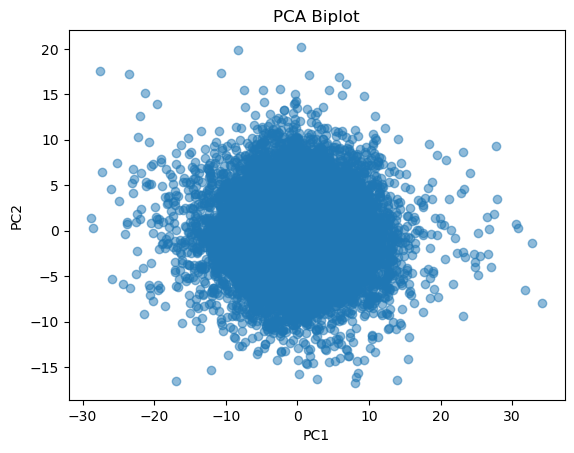

In [24]:
# Biplot (First Two Components)
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot')
plt.show()

In [25]:
pca_loadings = pca.components_.T
pca_loadings

array([[ 1.45554305e-05,  1.44843610e-03, -3.05569497e-03, ...,
         1.38069498e-03, -2.91613981e-03,  2.79404672e-04],
       [-1.40096983e-03,  6.21365922e-04,  2.29703774e-03, ...,
         3.91978785e-04, -4.52493919e-03,  3.56089883e-03],
       [-6.08830314e-04,  4.38767517e-03,  3.78666366e-03, ...,
        -7.02357703e-04, -3.00810282e-03, -7.93007564e-04],
       ...,
       [-2.62684336e-03,  1.99685730e-01,  1.65049284e-01, ...,
        -2.76988207e-03, -8.66052006e-03,  3.95328781e-03],
       [ 6.22399680e-02,  2.26622317e-01,  2.00714632e-01, ...,
        -5.86747926e-03, -1.93374555e-02,  7.64877669e-03],
       [-1.10436306e-02,  2.33526837e-01,  2.20270717e-01, ...,
         6.73206993e-03,  2.36519755e-02, -1.64911596e-02]])

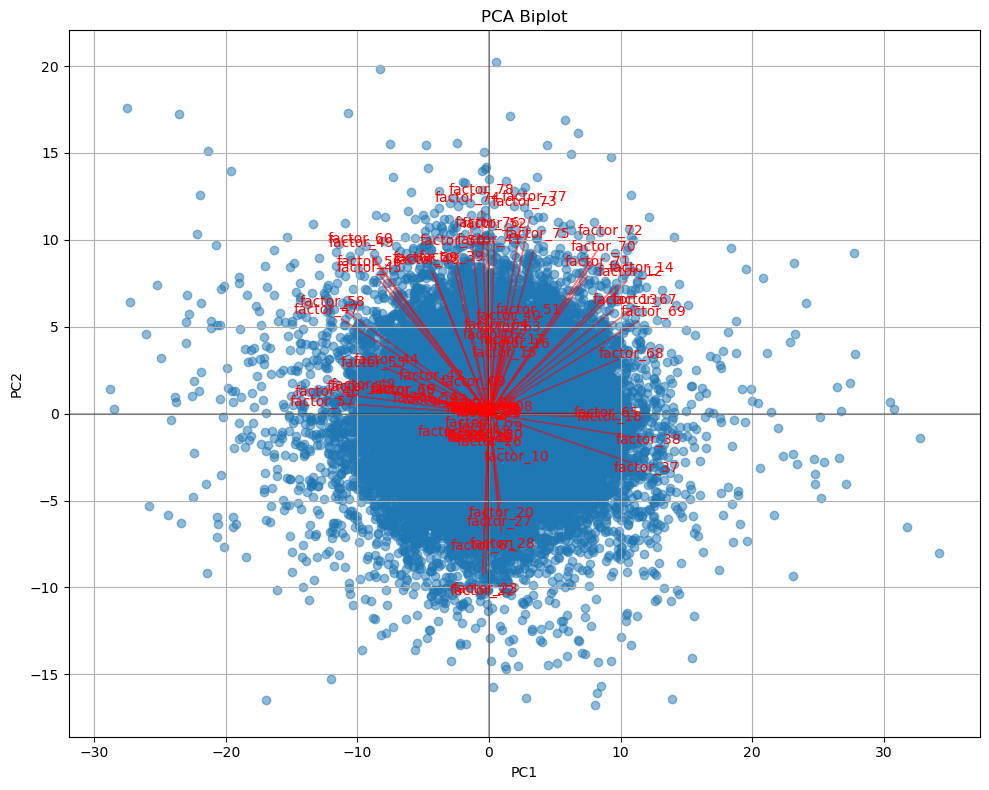

In [27]:
def create_biplot(score, loadings, feature_names, scale=5):
    '''
    该函数创建PCA双标图，展示数据在主成分空间的分布与原始特征的关系：  
    :param score:  主成分得分矩阵（转换后的数据点）
    :param loadings: 载荷矩阵（原始特征对主成分的贡献）
    :param feature_names: 特征名称列表
    :param scale: 载荷矢量的缩放因子（默认为5）
    :return: 
    '''
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Plot the scores
    plt.scatter(score[:, 0], score[:, 1], alpha=0.5)
    
    # Plot the loading vectors
    for i, (x, y) in enumerate(zip(loadings[:, 0], loadings[:, 1])):
        plt.arrow(0, 0, scale * x* 10, scale * y* 10, color='r', alpha=0.5)
        plt.text(scale * x * 11, scale * y * 11, feature_names[i], 
                color='r', ha='center', va='center')
    
    # Add labels and title
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA Biplot')
    
    # Add grid and axis lines
    plt.grid(True)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Get the feature names
feature_names = feature_cols

# Create the biplot with loading vectors
create_biplot(pca_result[:, :2], pca_loadings[:, :2], feature_names)

In [29]:
# create a DataFrame for the PCA loadings(number of components you choose before) 
columns = [f'PC{i+1}' for i in range(n_components)]
pc_df = pd.DataFrame(data=pca_result[:,:n_components], columns=columns)

# combine the PCA result with the index columns
pca_factors = pd.concat([indices.reset_index(drop=True), pc_df], axis=1)
pca_factors

,date_id,time_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
0,1600,0,-11.027432,-2.830727,-10.772373,-0.454745,-2.920534,-3.166407,0.261010,0.238102,...,-6.927885,-4.272618,2.975951,-5.522136,5.409348,2.477310,1.022673,-1.173537,1.755001,2.828113
1,1600,1,-4.020852,-7.664550,-3.550981,0.615579,-2.543170,-4.673520,-3.185883,-3.176676,...,-0.544804,-2.286689,1.668504,-4.525144,2.501619,3.728738,1.343281,1.589452,-0.848046,2.536157
2,1600,2,0.459617,-6.874857,-2.217384,0.649016,-0.629721,-5.324890,-1.329802,-6.322497,...,-0.063365,-3.096516,2.312605,-4.271744,1.540367,1.224879,0.423967,-1.134309,-1.152145,1.932805
3,1600,3,-0.931228,-1.907637,-2.050852,1.045124,-2.758425,-3.723868,1.053660,-5.970710,...,1.377440,-0.384709,1.887280,-3.294048,2.151529,0.638785,-0.992025,-0.694762,0.294364,2.727838
4,1600,4,-4.062104,-2.862231,-5.571439,2.064415,-3.947858,-6.270945,-4.518114,-5.265911,...,-3.527002,-1.176545,-0.938767,-5.838475,2.971566,-4.525828,-4.203946,0.670851,0.487018,0.222418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95827,1698,963,0.570905,2.432190,-0.578484,0.411507,0.039077,0.880083,-0.757335,1.675336,...,0.454325,-0.240831,0.106498,0.066000,-0.725986,0.068274,-0.352225,-0.221999,-0.653503,-0.574668
95828,1698,964,1.022545,1.474645,0.458752,1.525687,1.028555,1.324096,-1.340738,1.298218,...,-0.021817,-0.515316,0.907258,0.676187,-0.579334,0.048546,-0.016885,0.163538,0.270853,-0.084185
95829,1698,965,-0.059858,2.176267,-0.364375,0.195606,-0.312255,1.370042,-0.887982,0.649348,...,0.581112,-0.633572,-0.688748,-1.036570,-0.095865,-0.477579,0.153305,0.085437,-0.137247,-0.574170
95830,1698,966,-0.237114,2.747783,-0.335543,0.734246,-0.778793,1.588240,-0.664495,0.161311,...,0.907060,-0.706875,0.350852,-0.695843,-0.299935,0.515823,0.339618,0.363022,1.037632,0.048076


In [30]:
# 把生成的PCA因子全部转换为float32类型，但是注意date_id和time_id列的格式不要修改
# Convert all columns except index_cols to float32
convert_cols = [col for col in pca_factors.columns if col not in index_cols]
pca_factors[convert_cols] = pca_factors[convert_cols].astype(np.float32)
pca_factors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95832 entries, 0 to 95831
Data columns (total 42 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date_id  95832 non-null  int64  
 1   time_id  95832 non-null  int64  
 2   PC1      95832 non-null  float32
 3   PC2      95832 non-null  float32
 4   PC3      95832 non-null  float32
 5   PC4      95832 non-null  float32
 6   PC5      95832 non-null  float32
 7   PC6      95832 non-null  float32
 8   PC7      95832 non-null  float32
 9   PC8      95832 non-null  float32
 10  PC9      95832 non-null  float32
 11  PC10     95832 non-null  float32
 12  PC11     95832 non-null  float32
 13  PC12     95832 non-null  float32
 14  PC13     95832 non-null  float32
 15  PC14     95832 non-null  float32
 16  PC15     95832 non-null  float32
 17  PC16     95832 non-null  float32
 18  PC17     95832 non-null  float32
 19  PC18     95832 non-null  float32
 20  PC19     95832 non-null  float32
 21  PC20     958

In [31]:
# Save PCA results
pca_factors.to_parquet(f'../data/output/PCA_Factor_{day}_n{n_components}.parquet')